In [25]:
from statsmodels.tsa.x13 import x13_arima_analysis
from sympy import *
init_printing()
from IPython.display import Math
from sympy import Rational as R
from sklearn.datasets import fetch_lfw_people
from sklearn.decomposition import PCA
import numpy as np

# Sample mean and covariance matrix

In [4]:
X1 = Matrix([1, 2, 1])
X2 = Matrix([4, 2, 13])
X3 = Matrix([7, 8, 1])
X4 = Matrix([8, 4, 5])

In [5]:
# sample mean
N = 4
M = (1/N)*(X1 + X2 + X3 + X4)
M

⎡5.0⎤
⎢   ⎥
⎢4.0⎥
⎢   ⎥
⎣5.0⎦

In [6]:
X1_bar = X1 - M
X2_bar = X2 - M
X3_bar = X3 - M
X4_bar = X4 - M

In [7]:
B = Matrix.hstack(X1_bar, X2_bar, X3_bar, X4_bar)
B

⎡-4.0  -1.0  2.0   3.0⎤
⎢                     ⎥
⎢-2.0  -2.0  4.0    0 ⎥
⎢                     ⎥
⎣-4.0  8.0   -4.0   0 ⎦

In [8]:
S = (1/(N-1)) * (B * B.T)
S

⎡10.0  6.0    0  ⎤
⎢                ⎥
⎢6.0   8.0   -8.0⎥
⎢                ⎥
⎣ 0    -8.0  32.0⎦

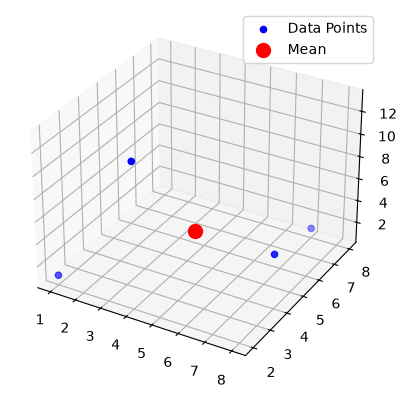

In [9]:
# plot data points, then the principal components as arrows from the mean
import matplotlib.pyplot as plt
# Convert sympy objects to floats for plotting
X1_f = [float(X1[0]), float(X1[1]), float(X1[2])]
X2_f = [float(X2[0]), float(X2[1]), float(X2[2])]
X3_f = [float(X3[0]), float(X3[1]), float(X3[2])]
X4_f = [float(X4[0]), float(X4[1]), float(X4[2])]
M_f = [float(M[0]), float(M[1]), float(M[2])]

# Plot data points and the mean
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')
ax.scatter([X1_f[0], X2_f[0], X3_f[0], X4_f[0]],
           [X1_f[1], X2_f[1], X3_f[1], X4_f[1]],
           [X1_f[2], X2_f[2], X3_f[2], X4_f[2]], color='b', label='Data Points')
ax.scatter([M_f[0]], [M_f[1]], [M_f[2]], color='r', s=100, label='Mean')
ax.legend()
plt.show()

# PCA

In [10]:
S = Matrix([[2382.78, 2611.84, 2136.20], [2611.84, 3106.47, 2553.90], [2136.20, 2553.90, 2650.71]])
eigenvectors = S.eigenvects()
eigenvectors

⎡⎛                     ⎡⎡0.541729504226801⎤⎤⎞  ⎛                     ⎡⎡0.68341 ↪
⎢⎜                     ⎢⎢                 ⎥⎥⎟  ⎜                     ⎢⎢        ↪
⎢⎜7614.23008449027, 1, ⎢⎢0.62947576355966 ⎥⎥⎟, ⎜98.1048093384954, 1, ⎢⎢-0.7156 ↪
⎢⎜                     ⎢⎢                 ⎥⎥⎟  ⎜                     ⎢⎢        ↪
⎣⎝                     ⎣⎣0.55703627111811 ⎦⎦⎠  ⎝                     ⎣⎣ 0.1441 ↪

↪ 4482307915 ⎤⎤⎞  ⎛                     ⎡⎡-0.489360592632865⎤⎤⎞⎤
↪            ⎥⎥⎟  ⎜                     ⎢⎢                  ⎥⎥⎟⎥
↪ 67237349577⎥⎥⎟, ⎜427.625106171235, 1, ⎢⎢-0.302622980745692⎥⎥⎟⎥
↪            ⎥⎥⎟  ⎜                     ⎢⎢                  ⎥⎥⎟⎥
↪ 0083537658 ⎦⎦⎠  ⎝                     ⎣⎣0.817890910759255 ⎦⎦⎠⎦

In [11]:
l1 = eigenvectors[0][0]
l2 = eigenvectors[2][0]
l3 = eigenvectors[1][0]
l1, l2, l3

In [12]:
v1 = eigenvectors[0][2][0]
v2 = eigenvectors[2][2][0]
v3 = eigenvectors[1][2][0]
v1, v2, v3

⎛⎡0.541729504226801⎤  ⎡-0.489360592632865⎤  ⎡0.683414482307915 ⎤⎞
⎜⎢                 ⎥  ⎢                  ⎥  ⎢                  ⎥⎟
⎜⎢0.62947576355966 ⎥, ⎢-0.302622980745692⎥, ⎢-0.715667237349577⎥⎟
⎜⎢                 ⎥  ⎢                  ⎥  ⎢                  ⎥⎟
⎝⎣0.55703627111811 ⎦  ⎣0.817890910759255 ⎦  ⎣ 0.14410083537658 ⎦⎠

In [13]:
x1, x2, x3 = symbols('x1 x2 x3')
# approximate v1, v2, v3 as numerical vectors
v1 = v1.evalf(2)
v2 = v2.evalf(2)
v3 = v3.evalf(2)

PC1 = v1[0]*x1 + v1[1]*x2 + v1[2]*x3
PC2 = v2[0]*x1 + v2[1]*x2 + v2[2]*x3
PC3 = v3[0]*x1 + v3[1]*x2 + v3[2]*x3
PC1, PC2, PC3

In [14]:
l1 = l1.round(2)
l2 = l2.round(2)
l3 = l3.round(2)

D = Matrix([[l1, 0, 0], [0, l2, 0], [0, 0, l3]])
D

⎡7614.23    0      0  ⎤
⎢                     ⎥
⎢   0     427.63   0  ⎥
⎢                     ⎥
⎣   0       0     98.1⎦

In [15]:
trace = l1 + l2 + l3
trace

In [16]:
explained1 = ((l1 / trace)*100).round(1)
explained2 = ((l2 / trace)*100).round(1)
explained3 = ((l3 / trace)*100).round(1)
explained1, explained2, explained3

## PCA on image data example

(The code below might take a while to run, since it loads the LFW dataset, which is quite large. Took 38 seconds on my PC.)

In [17]:
lfw_people = fetch_lfw_people(min_faces_per_person=100, resize=0.4)
n_samples, h, w = lfw_people.images.shape
X = lfw_people.data

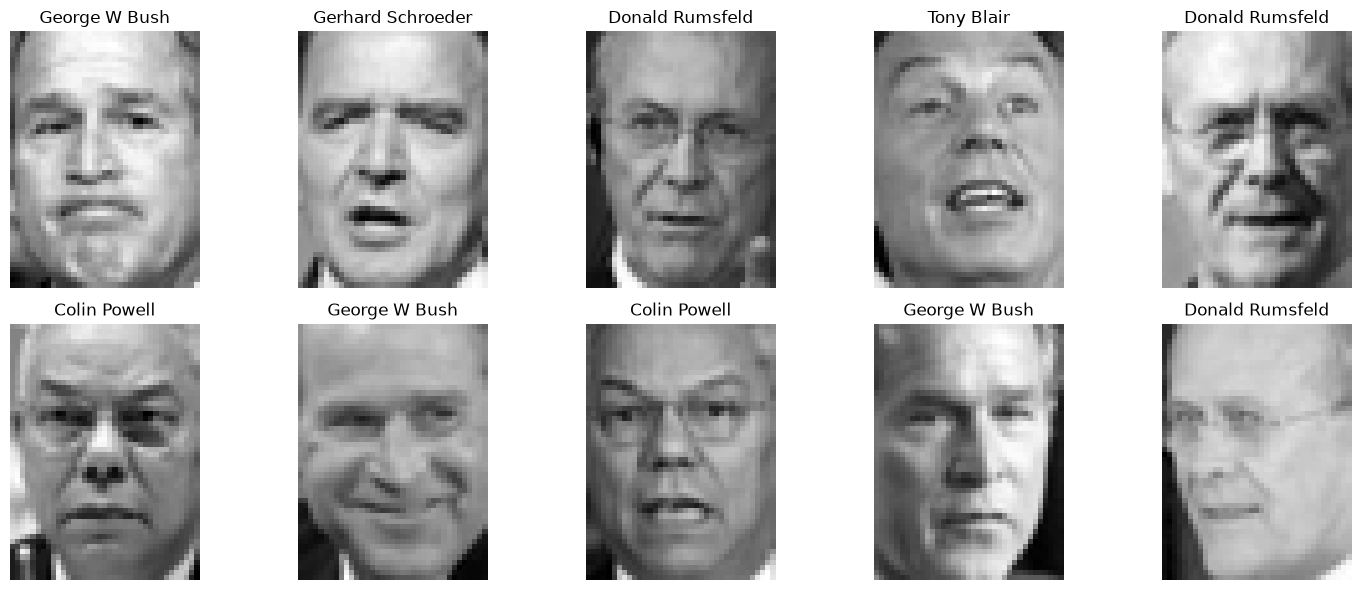

In [18]:
# visualize the first 10 images in the dataset
fig, axes = plt.subplots(2, 5, figsize=(15, 6))
for i, ax in enumerate(axes.flat):
    ax.imshow(lfw_people.images[i], cmap='gray')
    ax.set_title(lfw_people.target_names[lfw_people.target[i]])
    ax.axis('off')
plt.tight_layout()
plt.show()

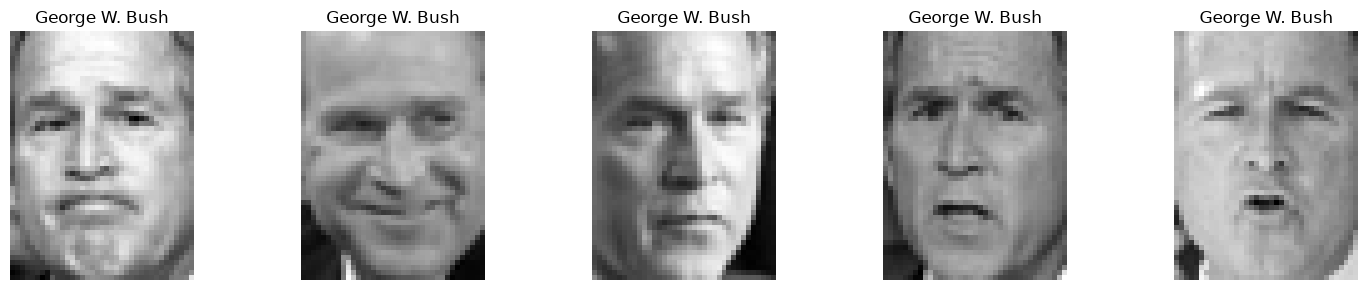

In [21]:
# show 5 images of George W. Bush
bush_indices = np.where(lfw_people.target == np.where(lfw_people.target_names == 'George W Bush')[0][0])[0]
fig, axes = plt.subplots(1, 5, figsize=(15, 3))
for i, ax in enumerate(axes.flat):
    ax.imshow(lfw_people.images[bush_indices[i]], cmap='gray')
    ax.set_title('George W. Bush')
    ax.axis('off')
plt.tight_layout()
plt.show()

In [22]:
def display_reconstructions(image, flat_image, original_shape, n_components_list):
    n_plots = len(n_components_list)
    cols = 3
    rows = (n_plots + 1 + cols - 1) // cols # +1 for the original image

    fig, axes = plt.subplots(rows, cols, figsize=(cols * 4, rows * 4),
                             subplot_kw={'xticks':[], 'yticks':[]})
    axes = axes.flatten()

    for i, n_components in enumerate(n_components_list):
        # 1. Set whiten=False for realistic reconstruction colors
        pca = PCA(n_components=n_components, whiten=False).fit(X)

        components = pca.transform(flat_image)
        reconstructed = pca.inverse_transform(components)

        # Reshape and handle the scale
        img_res = reconstructed.reshape(original_shape)

        # 2. Use 'gray' and let Matplotlib auto-scale the intensity
        axes[i].imshow(img_res, cmap='gray')
        axes[i].set_title(f"{n_components} Components")

    # Display original image in the next available slot
    axes[n_plots].imshow(image, cmap='gray')
    axes[n_plots].set_title("Original Image")

    # Hide any unused subplots
    for j in range(n_plots + 1, len(axes)):
        axes[j].axis('off')

    plt.tight_layout()
    plt.show()

In [23]:
def choose_image_and_display_reconstructions(image_index, n_components_list):
    image = lfw_people.images[image_index]
    flat_image = X[image_index].reshape(1, -1)
    display_reconstructions(image, flat_image, (h, w), n_components_list)

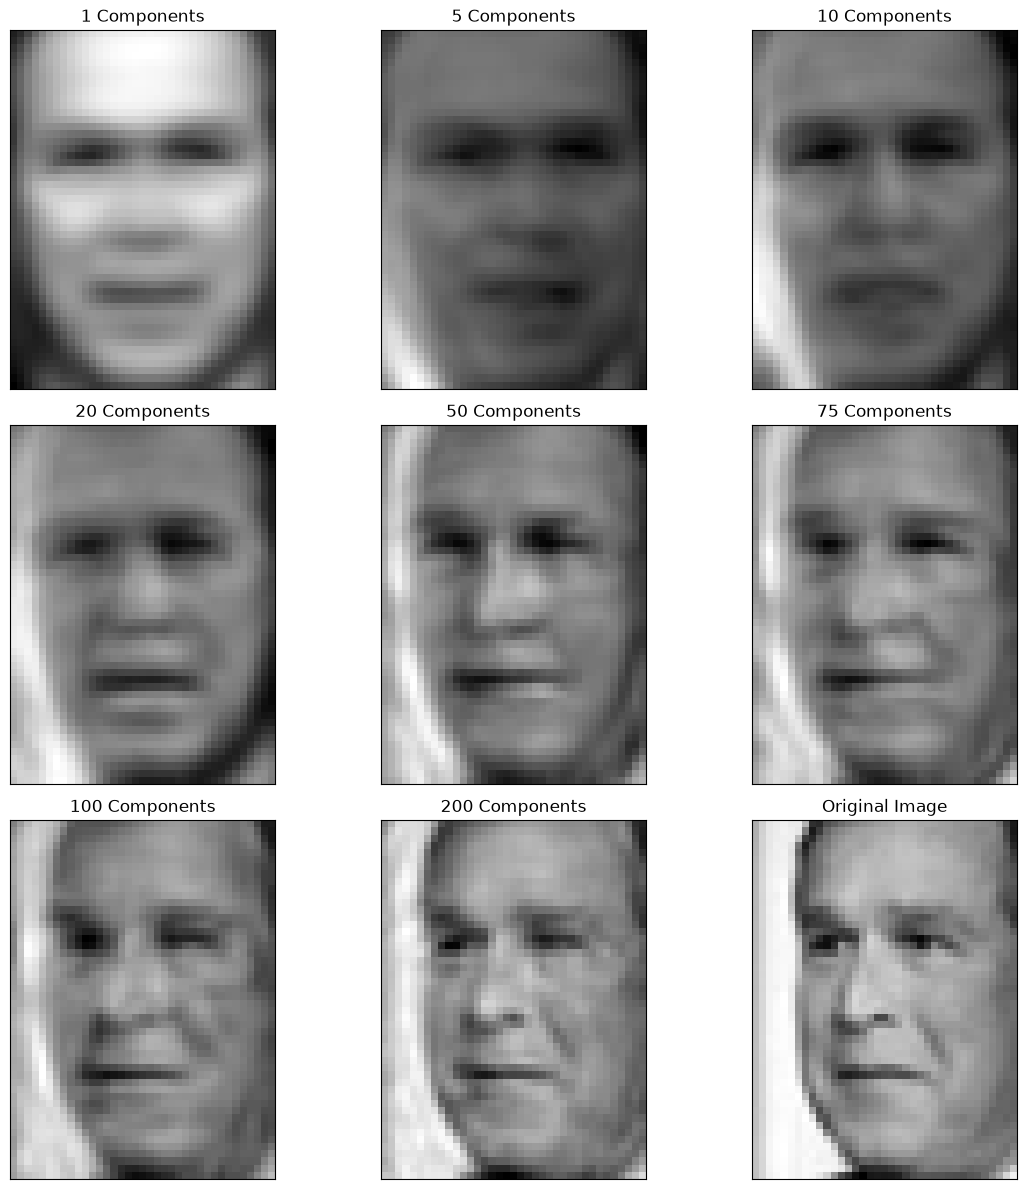

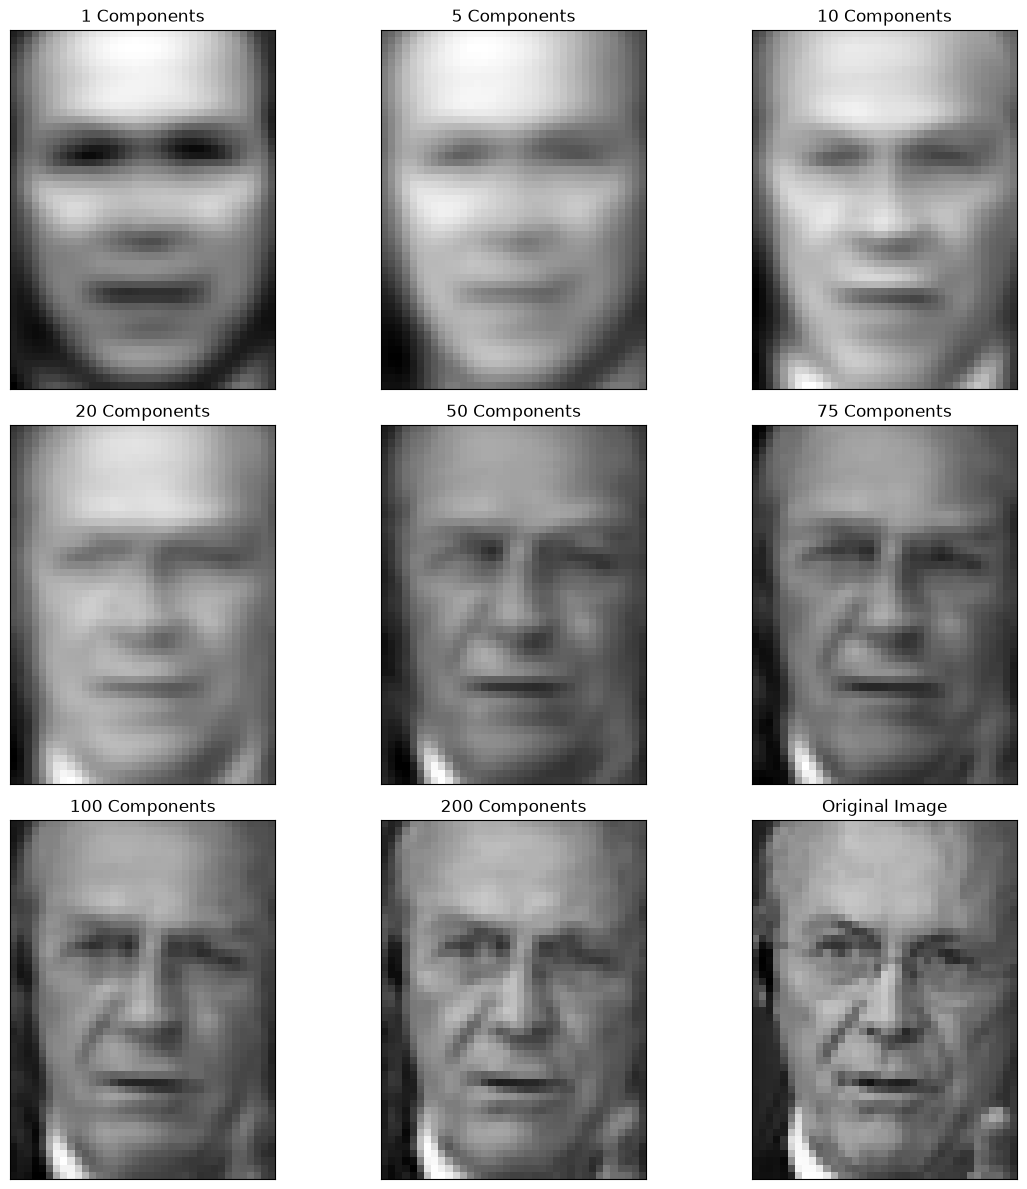

In [26]:
component_list = [1, 5, 10, 20, 50, 75, 100, 200]
choose_image_and_display_reconstructions(51, component_list)
choose_image_and_display_reconstructions(2, component_list)

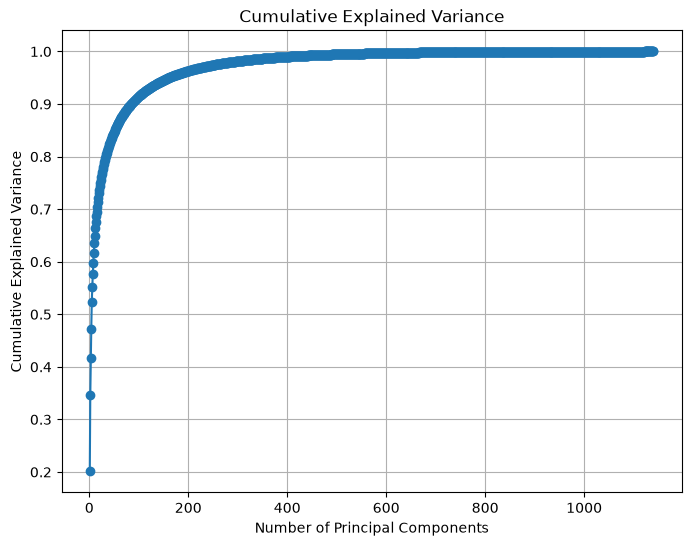

In [27]:
def visualize_elbow(X_data, title="Cumulative Explained Variance"):
    pca = PCA().fit(X_data)
    cumulative_explained_variance = np.cumsum(pca.explained_variance_ratio_)

    plt.figure(figsize=(8, 6))
    plt.plot(range(1, len(cumulative_explained_variance) + 1), cumulative_explained_variance, marker='o', linestyle='-')
    plt.xlabel('Number of Principal Components')
    plt.ylabel('Cumulative Explained Variance')
    plt.title(title)
    plt.grid(True)
    plt.show()

# Visualize the elbow to find the appropriate number of components
visualize_elbow(X)

In [28]:
def find_pca_thresholds(X_data, threshold=0.80):
    # 1. Fit PCA on the full dataset to see the total variance distribution
    # We use min(n_samples, n_features) as the maximum possible components
    pca = PCA().fit(X_data)

    # Calculate cumulative variance
    cumulative_variance = np.cumsum(pca.explained_variance_ratio_)

    # 2. Find the exact number of components for the threshold (e.g., 80%)
    # We add 1 because index is 0-based
    n_components_threshold = np.argmax(cumulative_variance >= threshold) + 1
    variance_at_threshold = cumulative_variance[n_components_threshold - 1]

    # 3. Visualization (Elbow Method)
    plt.figure(figsize=(10, 6))
    plt.plot(range(1, len(cumulative_variance) + 1), cumulative_variance,
             color='blue', lw=2, label='Cumulative Explained Variance')

    # Add a horizontal line for the threshold
    plt.axhline(y=threshold, color='r', linestyle='--',
                label=f'{int(threshold*100)}% Threshold')

    # Add a vertical line for the resulting n_components
    plt.axvline(x=n_components_threshold, color='g', linestyle=':',
                label=f'Required PCs: {n_components_threshold}')

    plt.title('PCA Elbow Method & Variance Threshold')
    plt.xlabel('Number of Principal Components')
    plt.ylabel('Cumulative Explained Variance')
    plt.legend(loc='best')
    plt.grid(True, alpha=0.3)
    plt.show()

    print(f"To explain {variance_at_threshold:.2%} of the variance, you need {n_components_threshold} components.")
    return n_components_threshold

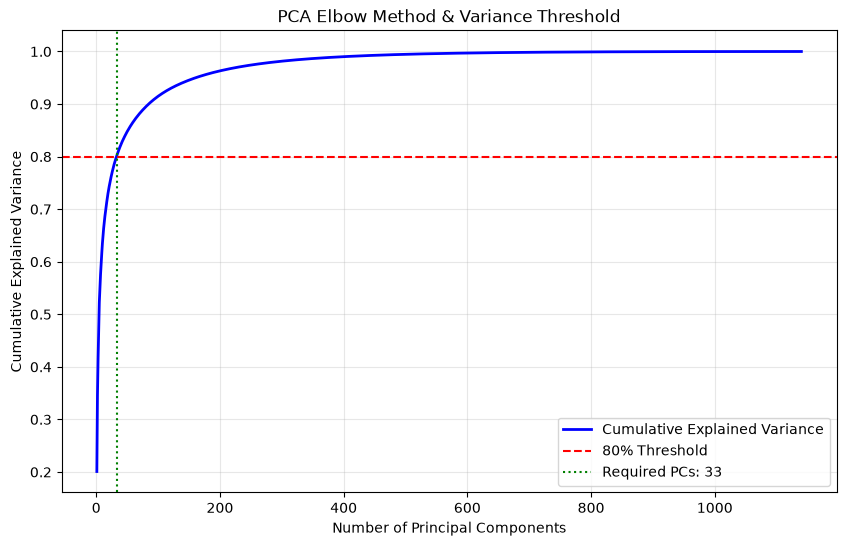

To explain 80.09% of the variance, you need 33 components.


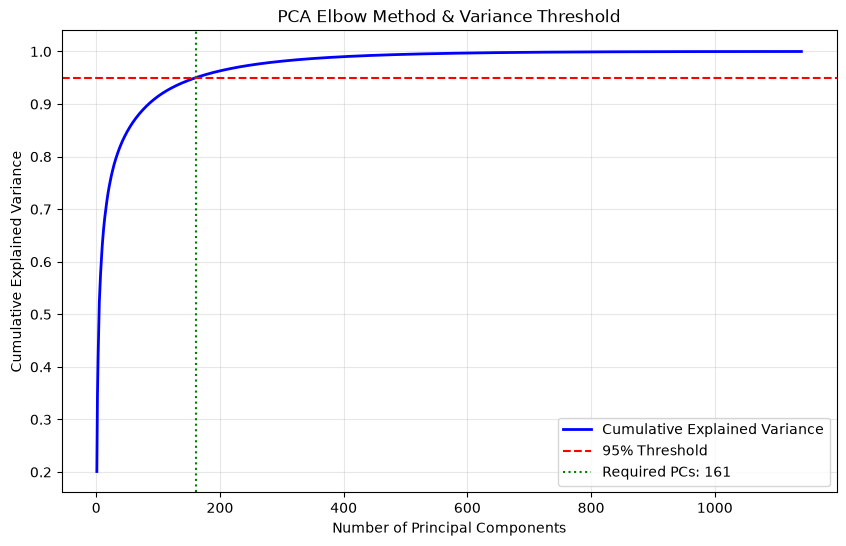

To explain 95.02% of the variance, you need 161 components.


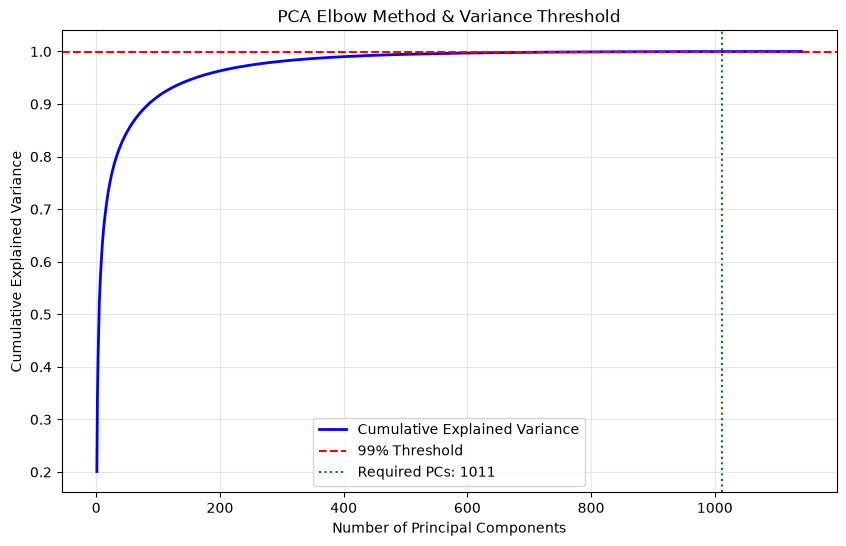

To explain 99.99% of the variance, you need 1011 components.


In [29]:
# Execute
n_80 = find_pca_thresholds(X, threshold=0.80)
n_95 = find_pca_thresholds(X, threshold=0.95)
n_100 = find_pca_thresholds(X, threshold=0.9999)  # Using 99.99% to approximate 100%